In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import flpoAgent 
import importlib 
import random 
from scipy.spatial.distance import cdist 
import createEnv 
from scipy.optimize import Bounds, LinearConstraint, minimize 
import supporting_functions 
from matplotlib.cm import get_cmap 

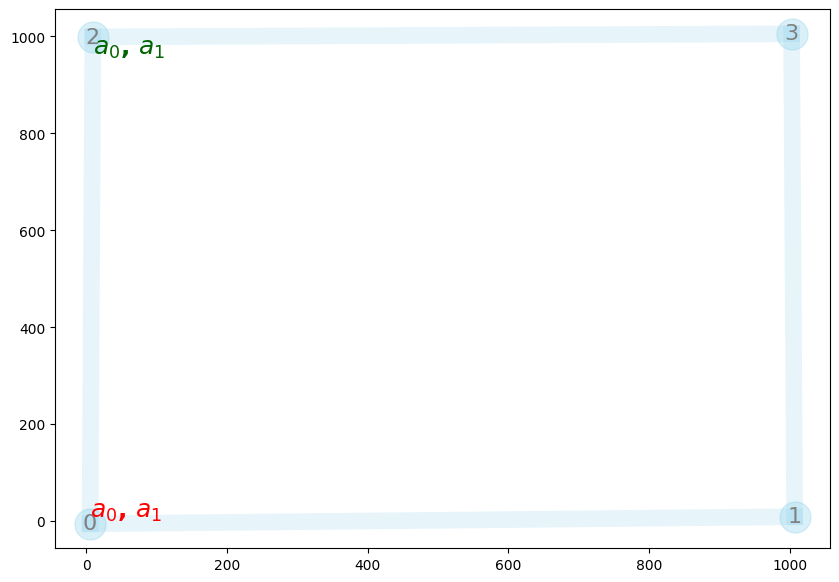

In [2]:
importlib.reload(flpoAgent)
importlib.reload(createEnv)
importlib.reload(supporting_functions)

# generate waypoints and the adjacency matrix
n_waypoints = 4
n_agents = 2
tolArray = np.random.uniform(10.0, 10.0, n_waypoints)

# Grid network parameters
grid_params = {
    'type':'grid',
    'n_points':n_waypoints,
    'grid_size':1000,
    'noise_factor':10
}

# Ring network parameters
ring_params = {
    'type':'ring',
    'num_rings':3,
    'points_per_ring':int(n_waypoints/3),
    'center_distance':1000,
    'deformation_level':50.0,
    'extra_connections':0.00,
    'missing_connections':0.05
}

# ellispoid cbf mode
ca_cbf_el = {
    'mode':'ellipse',
    'major_axis':1e-3*tolArray,
    'minor_axis':1e-4*tolArray,
    'degree':2
}

# linear cbf mode
ca_cbf_lin = {
    'mode':'linear',
    'eps':1e-4*tolArray,
    'eta':0
}

# cost mode options
cost_mode = 'sum' # 'slowest'
lm = 1 # for slowest

# create a mars environment
mars = createEnv.MARS(
    n_waypoints, 
    n_agents, 
    tolArray, 
    grid_params, 
    seed=13, 
    offset_energy=1,
    stagewiseCostCoeffs=np.array([1.0, 10.0, 1.0]),
    selfHop=0,
    ca_cbf=ca_cbf_lin,
    cost_mode=cost_mode,
    lm = lm,
    printFlag=False)

# mars visualization 
cmap = plt.get_cmap('tab20') 
agent_colors = {a: cmap(i / mars.n_agents) for i, a in enumerate(range(mars.n_agents))} 
createEnv.plotNetwork(mars=mars, figuresize=(10,7), routes=[], agent_colors=agent_colors, showEdgeLength=False) 

# agent visualization
# show_graph=0
# if show_graph:
#     for i,v in enumerate(mars.agents):
#         v.showGraph(mars.wp_locations, mars.dist_mat, mars.mask, mars.sched_mat[i,:], figuresize=(10,5), showEdgeTimeLim=True)



In [3]:
beta_min = 1e-3
beta_max = 1e3
beta_grow = 3
beta = beta_min
beta_arr = []
while beta <= beta_max:
    beta_arr.append(beta)
    beta = beta * beta_grow

T0 = mars.sched_mat
# T0 = np.ones((mars.n_agents, mars.n_waypoints))
# for i in range(mars.n_agents):
#     if i > 0:
#         T0[i] = T0[i-1] + mars.tolArray + np.random.uniform(0, 5, mars.tolArray.shape)
# T0 = np.random.uniform(0, 10, (mars.n_agents, mars.n_waypoints))
V0 = mars.speed_vec

optimizer_cbf_clf = {
    'name':'cbf_clf',
    'dt_init':0.1,
    'dt_min':1e-5,
    'dt_max':0.1,
    'Tf':10,
    'gamma':2,
    'alpha_s':100,
    'alpha_c':10,
    'alpha_r':100,
    'alpha_q':100,
    'p':1,
    'stop_tol':0.1,
    'stop_tol_weight':np.array([0, 0, 1, 0]),
    'verbose':0
}

optimizer_slsqp = {
    'name':'SLSQP',
    'stop_tol':0.1,
    'disp':False
}

optimizers = [optimizer_cbf_clf, optimizer_slsqp]


In [4]:
mars.ca_cbf = ca_cbf_el
cbf_mode = mars.ca_cbf['mode']
active_waypoints = range(mars.n_waypoints)
print(f'mars cbf mode: {cbf_mode}')
print(beta_arr) 

for optim in optimizers:
    name = optim['name']
    print(f'--------------------------------------')
    print(f'       solving using {name}           ')
    print(f'--------------------------------------')

    T, V, F, Pb_a = mars.anneal( 
        beta_arr, 
        T0, 
        V0, 
        active_waypoints=active_waypoints, 
        optimizer=optim,
        annealPrint=True)
    optim['T_final'] = T
    optim['V_final'] = V
    optim['F_final'] = F
    optim['Pb_a_final'] = Pb_a



mars cbf mode: ellipse
[0.001, 0.003, 0.009000000000000001, 0.027000000000000003, 0.08100000000000002, 0.24300000000000005, 0.7290000000000001, 2.1870000000000003, 6.561000000000001, 19.683000000000003, 59.04900000000001, 177.14700000000002, 531.441]
--------------------------------------
       solving using cbf_clf           
--------------------------------------
a:0.040	b:0.099

beta: 1.0000e-03	cost: 874.969	tolb: 5.928e-03	n_active_waypoints:4	tol_mag:10.00	Hminb:0.27	Hmaxb:61.18
a:4.782	b:2.647

beta: 3.0000e-03	cost: 413.521	tolb: 3.103e-02	n_active_waypoints:4	tol_mag:10.00	Hminb:181.71	Hmaxb:44561.61
a:16.895	b:5.475

beta: 9.0000e-03	cost: 261.501	tolb: 8.042e-03	n_active_waypoints:4	tol_mag:10.00	Hminb:494.75	Hmaxb:240299.90
a:35.070	b:7.191

beta: 2.7000e-02	cost: 233.456	tolb: 4.985e-02	n_active_waypoints:4	tol_mag:10.00	Hminb:30260.07	Hmaxb:785327.28
a:57.564	b:8.152

beta: 8.1000e-02	cost: 211.414	tolb: 9.386e-02	n_active_waypoints:4	tol_mag:10.00	Hminb:2.77	Hmaxb:18568

--------------------------------
       cbf_clf results           
--------------------------------
+----+--------+-------------------------+-------+--------+-------+---------------+--------+
| A  |   R    |            T            |   V   | V Mean | V Max |     V Lim     |  Cost  |
+----+--------+-------------------------+-------+--------+-------+---------------+--------+
| v0 | [2, 0] |      [10.11 23.14]      | 79.73 | 77.06  | 77.06 | [ 0.83 79.73] | 262.77 |
| v1 | [2, 0] | [-1.000e-02  1.329e+01] | 74.22 | 75.54  | 75.54 | [ 0.97 74.53] | 183.68 |
+----+--------+-------------------------+-------+--------+-------+---------------+--------+


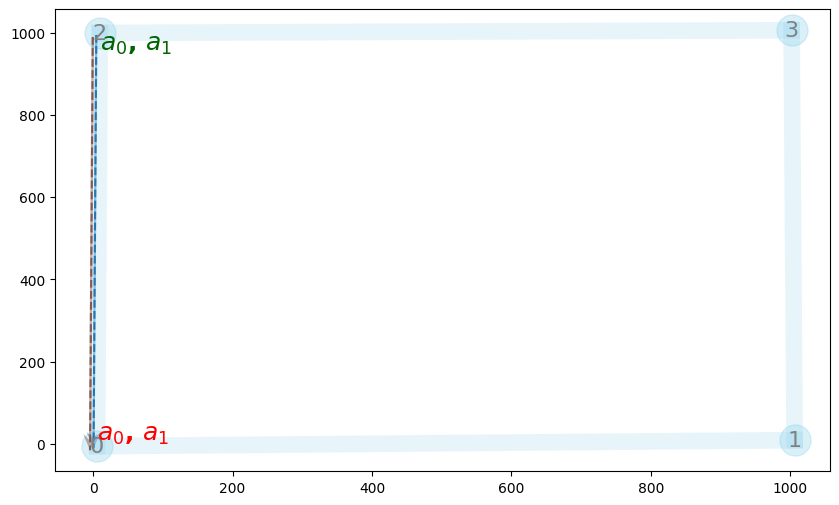

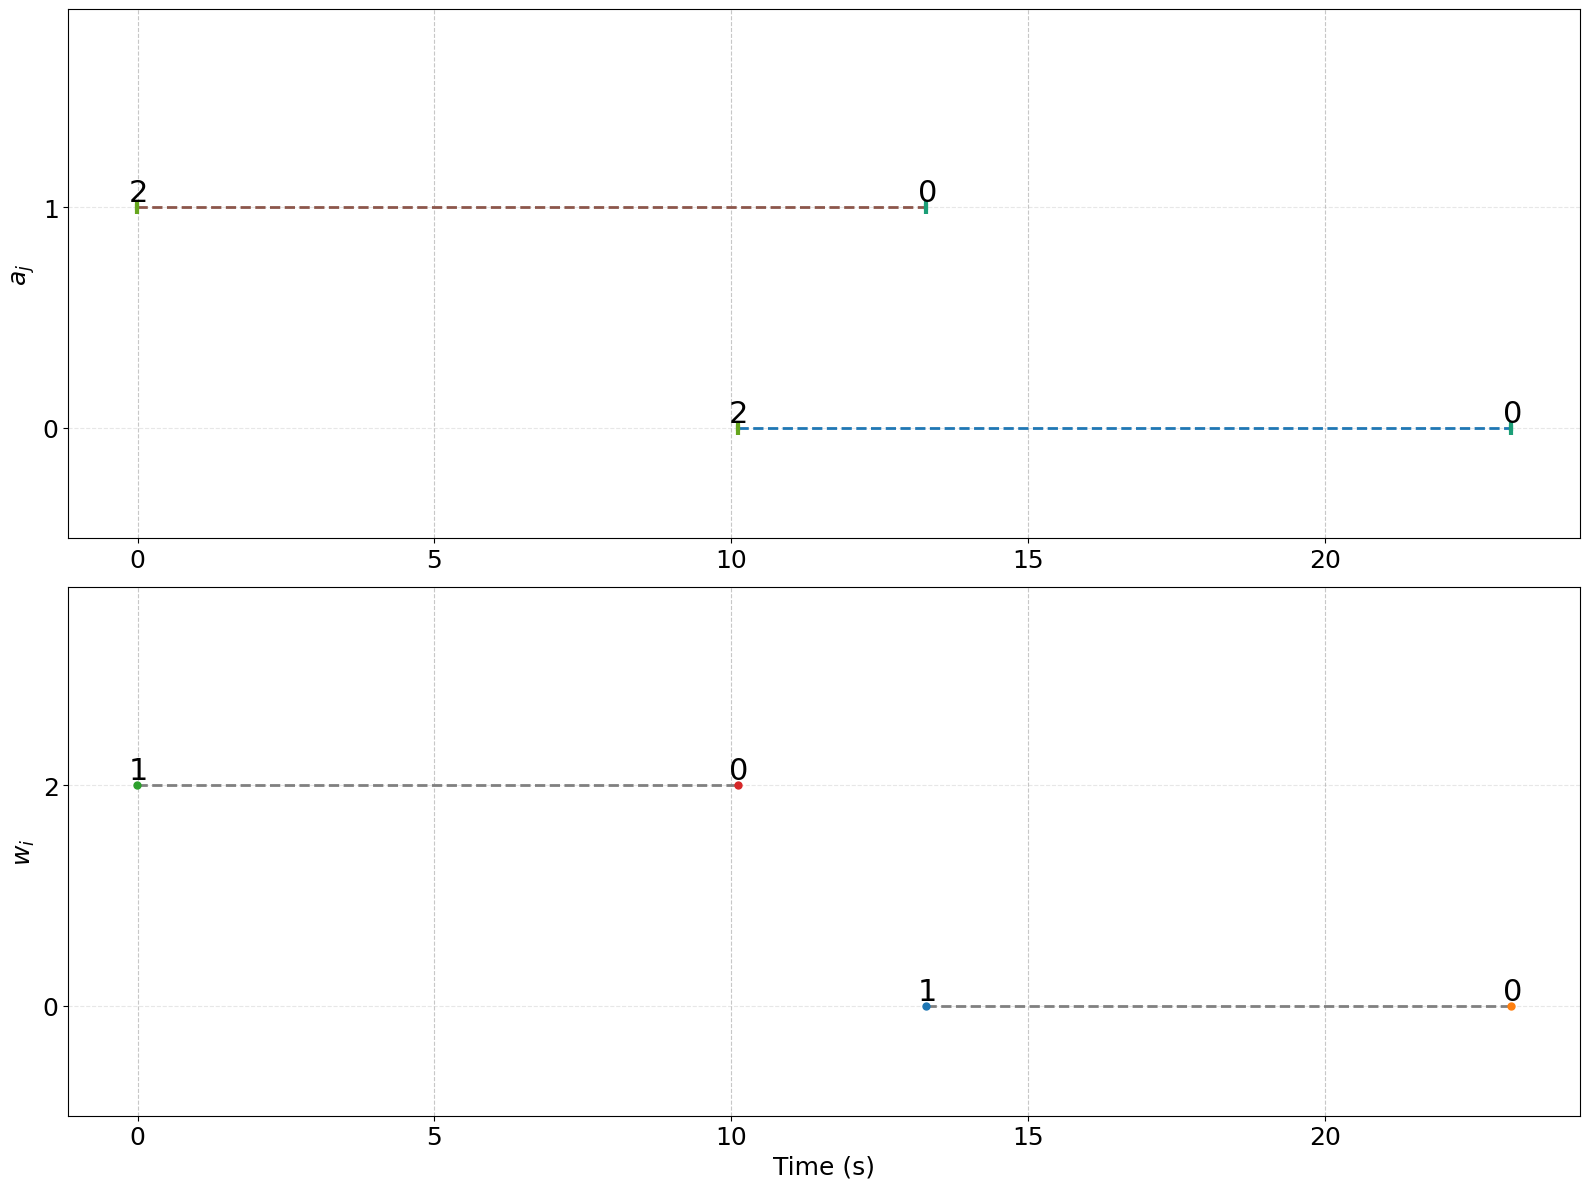

--------------------------------
       SLSQP results           
--------------------------------
+----+--------+---------------+-------+--------+-------+---------------+--------+
| A  |   R    |       T       |   V   | V Mean | V Max |     V Lim     |  Cost  |
+----+--------+---------------+-------+--------+-------+---------------+--------+
| v0 | [2, 0] | [ 0.   12.59] | 79.73 | 79.75  | 79.75 | [ 0.83 79.73] | 158.69 |
| v1 | [2, 0] | [ 9.95 23.42] | 74.53 | 74.56  | 74.56 | [ 0.97 74.53] | 280.54 |
+----+--------+---------------+-------+--------+-------+---------------+--------+


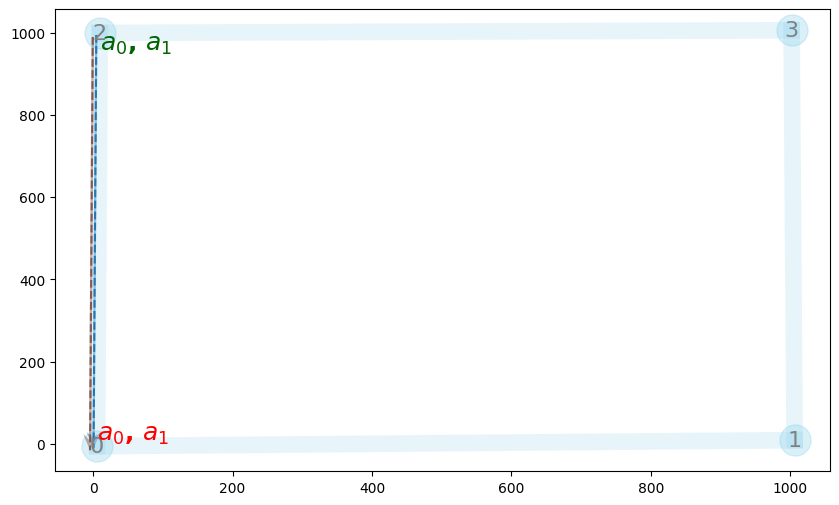

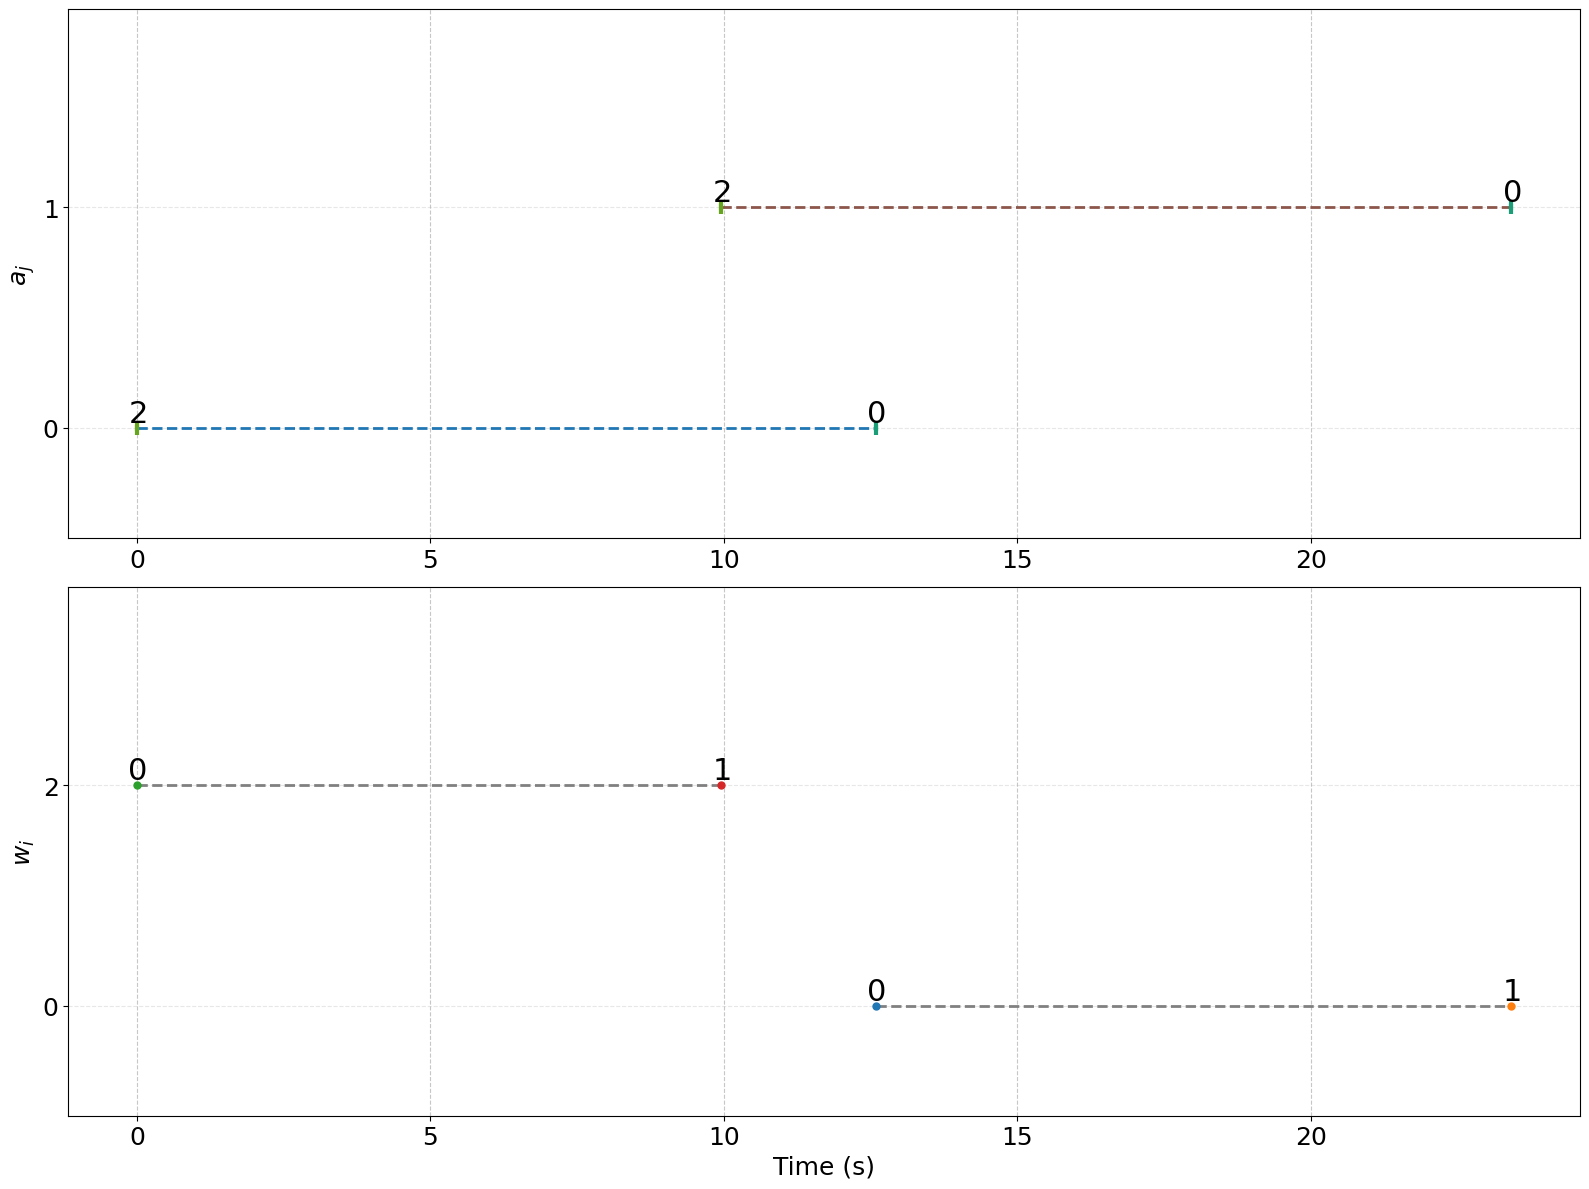

In [5]:
for optim in optimizers:
    name = optim['name']
    mars.sched_mat = optim['T_final']
    mars.speed_vec = optim['V_final']
    Pb_a = optim['Pb_a_final']

    print(f'--------------------------------')
    print(f'       {name} results           ')
    print(f'--------------------------------')

    agent_routes, agent_schedules = createEnv.show_solution_table( 
        mars, 
        Pb_a, 
        beta=beta_arr[-1], 
        printRoutes=True)
        
    createEnv.plotNetwork(
        mars=mars, 
        figuresize=(10,6), 
        routes=agent_routes, 
        agent_colors=agent_colors, 
        showEdgeLength=False) 

    reach_mat = mars.calc_agent_reach_mat_v1(
        mars.sched_mat,
        mars.speed_vec,
        beta=beta_arr[-1]
    )

    association_mat = np.ones(shape=reach_mat.shape)
    association_mat[reach_mat <= 1e-10] = 0.0

    createEnv.plot_waypoint_agent_schedules(
        agent_routes,
        agent_schedules,
        mars.sched_mat,
        association_mat,
        mars.process_T,
        agent_colors,
        figuresize=(16,12)
    )

